In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN, KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [2]:
PROJECT_ROOT = Path.cwd().parent
train_path = PROJECT_ROOT / "all_datasets" / "mall_customers_dataset" / "Mall_Customers.csv"
df = pd.read_csv(train_path)

In [3]:
features = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
X = StandardScaler().fit_transform(df[features])

kmeans = KMeans(n_clusters=5, n_init=30, random_state=42)
k_labels = kmeans.fit_predict(X)
print("KMeans silhouette:", round(silhouette_score(X, k_labels), 3))

KMeans silhouette: 0.417


In [4]:
# DBSCAN can mark observations as noise (-1) instead of forcing every row into a cluster.
dbscan = DBSCAN(eps=0.75, min_samples=6)
d_labels = dbscan.fit_predict(X)
mask = d_labels != -1
n_clusters = len(set(d_labels[mask]))
print("DBSCAN clusters:", n_clusters)
print("DBSCAN noise points:", int((~mask).sum()))
if n_clusters >= 2:
    print("DBSCAN silhouette (non-noise only):",
        round(silhouette_score(X[mask], d_labels[mask]), 3))

DBSCAN clusters: 1
DBSCAN noise points: 14


In [5]:
out = df.copy()
out["kmeans_cluster"] = k_labels
out["dbscan_cluster"] = d_labels
print(out.groupby("kmeans_cluster")[features].mean().round(1))

                 Age  Annual Income (k$)  Spending Score (1-100)
kmeans_cluster                                                  
0               46.2                26.8                    18.4
1               25.2                41.1                    62.2
2               32.9                86.1                    81.5
3               39.9                86.1                    19.4
4               55.6                54.4                    48.9


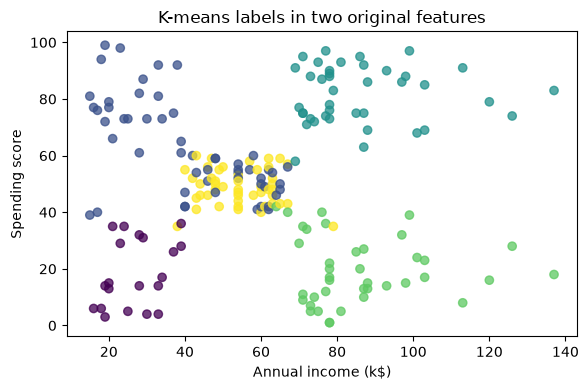

In [9]:
plt.figure(figsize=(6, 4))
plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=k_labels,
    alpha=0.75,
)
plt.xlabel("Annual income (k$)")
plt.ylabel("Spending score")
plt.title("K-means labels in two original features")
plt.tight_layout()
plt.show()

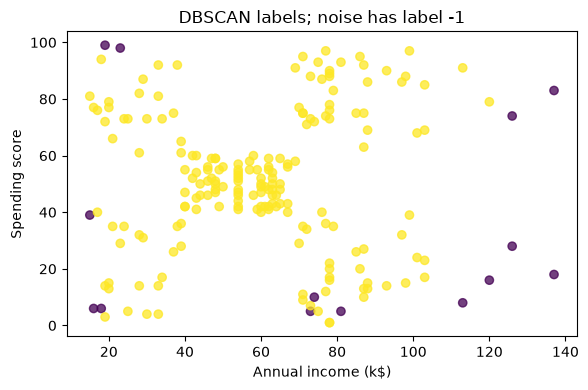

In [10]:
plt.figure(figsize=(6, 4))
plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=d_labels,
    alpha=0.75,
)
plt.xlabel("Annual income (k$)")
plt.ylabel("Spending score")
plt.title("DBSCAN labels; noise has label -1")
plt.tight_layout()
plt.show()